## Numerical Accuracy Benchmark for Triangular Matrix Inverse
 This notebook provides a reusable framework to compare the numerical accuracy of multiple algorithms as a function of input matrix size.

### Typical use cases:
 - Comparing different matrix inversion / multiplication algorithms
 - Studying stability vs size
 - Measuring forward/backward and absolute error

In [1]:
import numpy as np
import time
from typing import Callable, Dict

np.random.seed(0)


def generate_matrix(n: int, kind: str = "random", dtype=np.float64, scale: float=0.2) -> np.ndarray:
    """
    Generate test matrices of various types.

    Parameters
    ----------
    n : int
        Matrix dimension (n x n)
    kind : str
        Type of matrix: 'random', 'spd', 'hilbert', 'ill_conditioned'
    dtype : numpy dtype
    scale: float
        If the matrix type is random, it will be scaled by this factor.

    Returns
    -------
    A : ndarray (n x n)
    """
    if kind == "random":
        A = np.triu(scale * np.random.rand(n, n).astype(dtype))
        np.fill_diagonal(A, 1.0)
    elif kind == "random_0_5":
        A = np.triu(0.5 * np.random.rand(n, n).astype(dtype))
        np.fill_diagonal(A, 1.0)
    elif kind == "spd":
        M = np.random.randn(n, n)
        A = M.T @ M + n * np.eye(n)
    elif kind == "hilbert":
        i = np.arange(1, n + 1)
        A = 1.0 / (i[:, None] + i[None, :] - 1.0)
    elif kind == "ill_conditioned":
        U, _ = np.linalg.qr(np.random.randn(n, n))
        V, _ = np.linalg.qr(np.random.randn(n, n))
        s = np.logspace(0, -12, n)
        A = U @ np.diag(s) @ V.T
    else:
        raise ValueError(f"Unknown matrix kind: {kind}")

    return A.astype(dtype)

### Algorithms under consideration

In [ ]:
import numpy as np
from math import ceil

def reference_inverse(A: np.ndarray) -> np.ndarray:
    """High-accuracy reference using NumPy (double precision)."""
    return np.linalg.inv(A.astype(np.float64))

def algo_numpy_inv(A: np.ndarray) -> np.ndarray:
    return np.linalg.inv(A.astype(np.float32))


def tri_inv_vcs(A: np.ndarray) -> np.ndarray:
    """
    Compute the inverse of an invertible upper-triangular matrix U
    using the entrywise backward-substitution formula.

    Parameters
    ----------
    A : (n, n) ndarray
        Upper-triangular matrix of size n (with nonzero diagonals).

    Returns
    -------
    A_inv : Square matrix of size n.
        The inverse of A, also upper-triangular.
    """
    n = A.shape[0]
    A_inv = np.zeros_like(A, dtype=A.dtype)

    # Invert diagonal entries
    for i in range(n):
        A_inv[i, i] = 1.0 / A[i, i]

    # Compute upper-triangular off-diagonal entries
    for j in range(n):  # column
        # Compute each column backwards (from j - 1 down to 0)
        for i in range(j-1, -1, -1):
            s = 0.0
            for k in range(i+1, j+1):
                s -= (A[i, k] * A_inv[k, j]) / A[i, i]
            A_inv[i, j] = s

    return A_inv


def tri_inv_mcs(A: np.ndarray) -> np.ndarray:
  "Returns A^{-1} using backward substitution."
  n = A.shape[0]
  I_n = np.eye(n, dtype=A.dtype)

  A = 2 * I_n - A
  A_inv = I_n.copy()
  for k in reversed(range(n)):
    M = I_n.copy()
    M[:, k] = A[:, k]
    A_inv = M @ A_inv

  return A_inv


def tri_inv_mch(A: np.ndarray, max_block_size=0) -> np.ndarray:
    """
    Compute (I + A)^{-1} without explicit inversion
    """
    n = A.shape[0]
    if max_block_size == 0:
        max_block_size = n
    max_iters = int(ceil(np.log2(max_block_size // 2)))

    I = np.eye(n, dtype=A.dtype)
    X = 2 * I - A
    Y = (A - I).copy()
    for _ in range(max_iters):
        Y = Y @ Y
        X = X + X @ Y
    return X


def tri_inv_mbh(A: np.ndarray, X = None, starting_block_size = 1) -> np.ndarray:
    def even_blocks(A: np.ndarray, bsz) -> np.ndarray:
      n = A.shape[0]
      B = np.zeros((n, n), dtype=A.dtype)
      for idx in range(0, n, 2 * bsz):
          B[idx:idx + bsz, idx:idx + bsz] = A[idx:idx + bsz, idx:idx + bsz]
      return B

    def odd_blocks(A: np.ndarray, bsz) -> np.ndarray:
      n = A.shape[0]
      B = np.zeros((n, n), dtype=A.dtype)
      for idx in range(bsz, n, 2 * bsz):
          B[idx:idx + bsz, idx:idx + bsz] = A[idx:idx + bsz, idx:idx + bsz]
      return B

    n = A.shape[0]
    I = np.eye(n).astype(A.dtype)
    MA = -(A - I)
    if X is None:
        X = I.copy()
    block_size = starting_block_size
    while block_size < n:
        LX = even_blocks(X, block_size)
        RX = odd_blocks(X, block_size)
        X = (LX @ MA + I) @ RX + LX
        block_size = block_size * 2
    return X


def tri_inv_mxr(A):
    def diag_blocks(A: np.ndarray, bsz) -> np.ndarray:
      n = A.shape[0]
      B = np.zeros((n, n), dtype=A.dtype)
      for idx in range(0, n, bsz):
          B[idx:idx + bsz, idx:idx + bsz] = A[idx:idx + bsz, idx:idx + bsz]
      return B
    n = A.shape[0]
    block_size = 16
    DA = diag_blocks(A, block_size)
    X = tri_inv_mch(DA, max_block_size=block_size)
    X = tri_inv_mbh(A, X, starting_block_size=block_size)
    return X

# Example placeholder for a custom algorithm
# def algo_custom(A: np.ndarray) -> np.ndarray:
#     ...

ALGORITHMS: Dict[str, Callable[[np.ndarray], np.ndarray]] = {
    "np_inv(fp32)": algo_numpy_inv,
    "VCS": tri_inv_vcs,
    "MCS": tri_inv_mcs,
    "MCH": tri_inv_mch,
    "MBH": tri_inv_mbh,
    "MXR": tri_inv_mxr,
}


### Accuracy metrics (forward/backward error)

In [4]:
import numpy as np
from numpy.linalg import norm

def max_abs_error(X_hat: np.ndarray, X_ref: np.ndarray) -> float:
    """max(abs(X_hat - X_ref))"""
    return np.max(np.abs(X_hat - X_ref))

def max_rel_error(X_hat: np.ndarray, X_ref: np.ndarray) -> float:
    """max(abs(X_hat - X_ref) / abs(X_ref))"""
    max_error = 0
    n = X_hat.shape[0]
    for i in range(n):
        for j in range(n):
            if X_ref[i,j] == 0:
                continue
            err_ij = np.abs(X_hat[i,j] - X_ref[i,j]) / np.abs(X_ref[i,j])
            max_error = max_error if err_ij < max_error else err_ij
    return max_error

def frobenius_rel_error(X_hat: np.ndarray, X_ref: np.ndarray) -> float:
    """||X_hat - X_ref||_F / ||X_ref||_F"""
    return norm(X_hat - X_ref, ord='fro') / norm(X_ref, ord='fro')


def backward_abs_error(A: np.ndarray, X_hat: np.ndarray) -> float:
    """||I - A X_hat||_F"""
    n = A.shape[0]
    I = np.eye(n, dtype=X_hat.dtype)
    return norm(I - A @ X_hat, ord='fro')

### Benchmark runner

In [ ]:
from dataclasses import dataclass
from typing import List

@dataclass
class BenchmarkConfig:
    sizes: List[int]
    dtypes: List[np.dtype]
    matrix_kind: str = "random"
    matrix_scale: float = 0.5
    repeats: int = 3

@dataclass
class Result:
    size: int
    algo: str
    dtype: str
    frobenius_rel_err: float
    backward_abs_err: float
    max_abs_err: float
    max_rel_err: float
    time_sec: float


def run_benchmark(config: BenchmarkConfig) -> List[Result]:
    results: List[Result] = []
    ref_dtype = np.float64
    for dtype in config.dtypes:
        for n in config.sizes:
            A = generate_matrix(n, kind=config.matrix_kind, dtype=dtype, scale=config.matrix_scale)
            # reference always computed in float64 for stability
            X_ref = reference_inverse(A)

            for algo_name, algo_fn in ALGORITHMS.items():
                frobenius_rel_errs = []
                backward_abs_errs = []
                max_abs_errs = []
                max_rel_errs = []
                times = []

                for _ in range(config.repeats):
                    start = time.perf_counter()
                    X_hat = algo_fn(A)
                    elapsed = time.perf_counter() - start
                    X_hat_in_ref_dtype = X_hat.astype(ref_dtype)

                    frobenius_rel_errs.append(frobenius_rel_error(X_hat_in_ref_dtype, X_ref))
                    backward_abs_errs.append(backward_abs_error(A, X_hat_in_ref_dtype))
                    max_abs_errs.append(max_abs_error(X_hat_in_ref_dtype, X_ref))
                    max_rel_errs.append(max_rel_error(X_hat_in_ref_dtype, X_ref))
                    times.append(elapsed)

                results.append(Result(
                    size=n,
                    algo=algo_name,
                    dtype=np.dtype(dtype).name,
                    frobenius_rel_err=float(np.mean(frobenius_rel_errs)),
                    backward_abs_err=float(np.mean(backward_abs_errs)),
                    max_abs_err=float(np.mean(max_abs_errs)),
                    max_rel_err=float(np.mean(max_abs_errs)),
                    time_sec=float(np.mean(times)),
                ))

    return results

## Run Benchmark


In [6]:
config = BenchmarkConfig(
    sizes=[16, 32, 64, 128],
    dtypes=[np.float32, np.float16],
    matrix_kind="random",
    matrix_scale=0.5,
    repeats=3,
)

results = run_benchmark(config)

/tmp/ipykernel_2174438/1641272738.py:83: RuntimeWarning: overflow encountered in matmul
  X = X + X @ Y
/tmp/ipykernel_2174438/1641272738.py:83: RuntimeWarning: overflow encountered in add
  X = X + X @ Y
/tmp/ipykernel_2174438/1641272738.py:82: RuntimeWarning: overflow encountered in matmul
  Y = Y @ Y
/tmp/ipykernel_2174438/1641272738.py:83: RuntimeWarning: invalid value encountered in matmul
  X = X + X @ Y
/tmp/ipykernel_2174438/1641272738.py:82: RuntimeWarning: invalid value encountered in matmul
  Y = Y @ Y


### Process results

In [8]:
import pandas as pd

df = pd.DataFrame([r.__dict__ for r in results])
df.head(25)


,size,algo,dtype,frobenius_rel_err,backward_abs_err,max_abs_err,max_rel_err,time_sec
0,16,np_inv(fp32),float32,1.133524e-08,6.764707e-08,1.481090e-08,1.481090e-08,0.000087
1,16,VCS,float32,1.534880e-08,6.435216e-08,1.934454e-08,1.934454e-08,0.001046
2,16,MCS,float32,2.597820e-08,1.041505e-07,3.808567e-08,3.808567e-08,0.000279
3,16,MCH,float32,8.188317e-08,3.737424e-07,1.840205e-07,1.840205e-07,0.000060
4,16,MCH+IR,float32,3.024572e-08,1.307769e-07,4.940952e-08,4.940952e-08,0.000056
5,16,MBH,float32,2.493149e-08,1.335868e-07,5.132129e-08,5.132129e-08,0.000160
6,16,MBH+IR,float32,3.315027e-08,1.533663e-07,6.788800e-08,6.788800e-08,0.000108
7,16,MXR,float32,8.188317e-08,3.737424e-07,1.840205e-07,1.840205e-07,0.000055
8,16,MXR+IR,float32,3.024572e-08,1.307769e-07,4.940952e-08,4.940952e-08,0.000059
9,16,Newton-Schulz,float32,3.580649e-02,8.570395e-02,4.823225e-02,4.823225e-02,0.000183


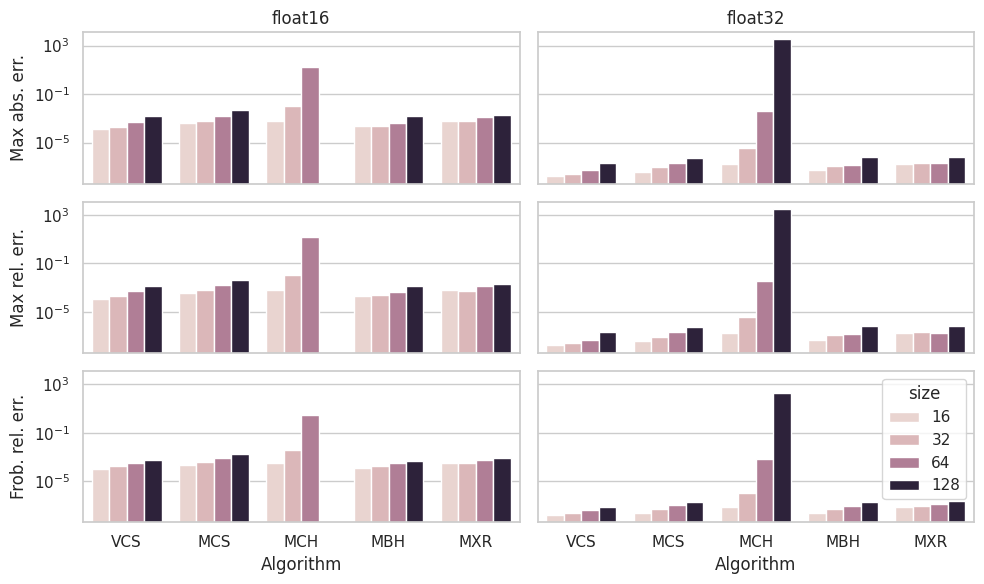

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn style
sns.set_theme(style="whitegrid")

# Ensure consistent algorithm order
algo_order = ALGORITHMS.keys()

plot_df_fp16 = df[(df["dtype"] == "float16")].copy()
plot_df_fp32 = df[(df["dtype"] == "float32")].copy()

fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(10, 6), sharex=True, sharey=True)

abs_err_plot_fp16 = sns.barplot(
    data=plot_df_fp16,
    x="algo",
    y="max_abs_err",
    hue="size",              # grouped bars by matrix size
    order=algo_order,
    estimator="mean",        # or "median" (often better for errors)
    errorbar=None,             # disable CI bars (paper-friendly)
    ax=ax[0,0],
    
)
rel_err_plot_fp16 = sns.barplot(
    data=plot_df_fp16,
    x="algo",
    y="max_rel_err",
    hue="size",              # grouped bars by matrix size
    order=algo_order,
    estimator="mean",        # or "median" (often better for errors)
    errorbar=None,             # disable CI bars (paper-friendly)
    ax=ax[1,0]
)
frob_err_plot_fp16 = sns.barplot(
    data=plot_df_fp16,
    x="algo",
    y="frobenius_rel_err",
    hue="size",              # grouped bars by matrix size
    order=algo_order,
    estimator="mean",        # or "median" (often better for errors)
    errorbar=None,             # disable CI bars (paper-friendly)
    ax=ax[2,0]
)

abs_err_plot_fp32 = sns.barplot(
    data=plot_df_fp32,
    x="algo",
    y="max_abs_err",
    hue="size",              # grouped bars by matrix size
    order=algo_order,
    estimator="mean",        # or "median" (often better for errors)
    errorbar=None,             # disable CI bars (paper-friendly)
    ax=ax[0,1],
    
)
rel_err_plot_fp32 = sns.barplot(
    data=plot_df_fp32,
    x="algo",
    y="max_rel_err",
    hue="size",              # grouped bars by matrix size
    order=algo_order,
    estimator="mean",        # or "median" (often better for errors)
    errorbar=None,             # disable CI bars (paper-friendly)
    ax=ax[1,1]
)
frob_err_plot_fp32 = sns.barplot(
    data=plot_df_fp32,
    x="algo",
    y="frobenius_rel_err",
    hue="size",              # grouped bars by matrix size
    order=algo_order,
    estimator="mean",        # or "median" (often better for errors)
    errorbar=None,             # disable CI bars (paper-friendly)
    ax=ax[2,1]
)

for axis in ax[0]:
    axis.set_yscale("log")
for axis in ax[1]:
    axis.set_yscale("log")
for axis in ax[2]:
    axis.set_yscale("log")
ax[0,0].set_ylabel("Max abs. err.")
ax[1,0].set_ylabel("Max rel. err.")
ax[2,0].set_ylabel("Frob. rel. err.")
ax[2,0].set_xlabel("Algorithm")
ax[2,1].set_xlabel("Algorithm")
ax[0,0].set_title(f"float16")
ax[0,1].set_title(f"float32")
ax[0,0].legend(ncols=4)
abs_err_plot_fp16.legend_.remove()
abs_err_plot_fp32.legend_.remove()
rel_err_plot_fp16.legend_.remove()
rel_err_plot_fp32.legend_.remove()
frob_err_plot_fp16.legend_.remove()

plt.tight_layout()
plt.show()


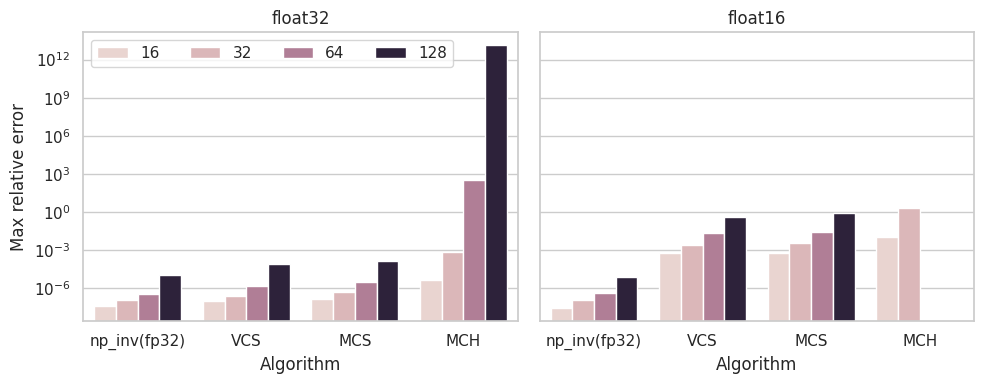

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Seaborn style
sns.set_theme(style="whitegrid")

# Ensure consistent algorithm order
algo_order = [
    "np_inv(fp32)",
    "VCS",
    "MCS",
    "MCH",
]


plot_df_fp32 = df[(df["dtype"] == "float32")].copy()
plot_df_fp16 = df[(df["dtype"] == "float16")].copy()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4), sharey=True)

fp32_plot = sns.barplot(
    data=plot_df_fp32,
    x="algo",
    y="max_rel_err",
    hue="size",              # grouped bars by matrix size
    order=algo_order,
    estimator="mean",        # or "median" (often better for errors)
    errorbar=None,             # disable CI bars (paper-friendly)
    ax=ax[0]
)
fp16_plot = sns.barplot(
    data=plot_df_fp16,
    x="algo",
    y="max_rel_err",
    hue="size",              # grouped bars by matrix size
    order=algo_order,
    estimator="mean",        # or "median" (often better for errors)
    errorbar=None,             # disable CI bars (paper-friendly)
    ax=ax[1]
)

for axis in ax:
    axis.set_yscale("log")
    axis.set_xlabel("Algorithm")
ax[0].set_ylabel("Max relative error")

ax[0].set_title(f"float32")
ax[1].set_title(f"float16")
fp32_plot.legend_.remove()
fp16_plot.legend_.remove()
ax[0].legend(ncols=4)

plt.tight_layout()
plt.show()

### Save results to output

In [63]:
# Save results to CSV for paper-quality plots
output_csv = "numerical_accuracy_results.csv"
df.to_csv(output_csv, index=False)
print(f"Results saved to {output_csv}")

Results saved to numerical_accuracy_results.csv
